In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [2]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

## 1. Загрузка данных

In [3]:
operations = pd.read_excel('../data/dataset.xlsx', sheet_name = 'Данные')
operations['dtime_pay'] = pd.to_datetime(operations['dtime_pay'], format = "%Y-%m-%d %H:%M%S")
operations.name = "operations"
operations.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174


In [4]:
clients = pd.read_excel('../data/dataset.xlsx', sheet_name = 'Clients')
clients['dtime_ad'] = pd.to_datetime(clients['dtime_ad'], format = "%Y-%m-%d %H:%M%S")
clients.name = "clients"
clients.head()

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [5]:
regions = pd.read_excel('../data/dataset.xlsx', sheet_name = 'Region_dict')
regions.name = "regions"
regions.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


In [6]:
dataset_list = [operations, clients, regions]

## 2. Обработка данных

### 2.1. Пропуски

In [7]:
def nan_searcher(dataframe):
    print(f"""
{dataframe.name}
Строк с пропусками: {dataframe[dataframe.isna().any(axis=1)].shape[0]}
Процент строк с пропусками: {dataframe[dataframe.isna().any(axis=1)].shape[0] / dataframe.shape[0]:.3f} %
Детальная разбивка по столбцам:
{round((dataframe.isna().sum() / len(dataframe)) * 100, 3)}
\n
""")

In [8]:
for elem in dataset_list:
    nan_searcher(elem)


operations
Строк с пропусками: 2429
Процент строк с пропусками: 0.064 %
Детальная разбивка по столбцам:
id_order       0.000
id_client      1.548
amt_payment    5.644
dtime_pay      6.394
dtype: float64




clients
Строк с пропусками: 249
Процент строк с пропусками: 0.004 %
Детальная разбивка по столбцам:
id_client           0.000
dtime_ad            0.448
nflag_test          0.000
id_trading_point    0.000
dtype: float64




regions
Строк с пропусками: 0
Процент строк с пропусками: 0.000 %
Детальная разбивка по столбцам:
id_trading_point    0.0
city                0.0
dtype: float64





В таблицах немного строк с пропусками: максимум 6% от всего объёма данных. Удалим их.

In [9]:
def dataframe_dropna(dataframe):
    dataframe.dropna(inplace = True)

In [10]:
for elem in dataset_list:
    dataframe_dropna(elem)

In [11]:
# Проверка:
for elem in dataset_list:
    nan_searcher(elem)


operations
Строк с пропусками: 0
Процент строк с пропусками: 0.000 %
Детальная разбивка по столбцам:
id_order       0.0
id_client      0.0
amt_payment    0.0
dtime_pay      0.0
dtype: float64




clients
Строк с пропусками: 0
Процент строк с пропусками: 0.000 %
Детальная разбивка по столбцам:
id_client           0.0
dtime_ad            0.0
nflag_test          0.0
id_trading_point    0.0
dtype: float64




regions
Строк с пропусками: 0
Процент строк с пропусками: 0.000 %
Детальная разбивка по столбцам:
id_trading_point    0.0
city                0.0
dtype: float64





### 2.2. Дубликаты.

In [12]:
operations[operations.duplicated(['id_order', 'id_client'])]

,id_order,id_client,amt_payment,dtime_pay


In [13]:
clients[clients.duplicated('id_client')]

,id_client,dtime_ad,nflag_test,id_trading_point


In [14]:
regions[regions.duplicated('id_trading_point')]

,id_trading_point,city


По уникальным идентификаторам строк в таблицах повторов не обнаружено

### 2.3. Обработка специфических данных.

In [15]:
for el in dataset_list:
    print(f"""
{el.name}\n
{el.dtypes}\n
{el.describe(include='all', datetime_is_numeric=True)}\n\n
""")


operations

id_order                int64
id_client             float64
amt_payment           float64
dtime_pay      datetime64[ns]
dtype: object

            id_order      id_client   amt_payment  \
count   35560.000000   35560.000000  35560.000000   
mean   197768.890804  194089.864511   3542.339623   
min    100238.000000  178561.000000    498.000000   
25%    148567.000000  186352.750000   2581.000000   
50%    197639.500000  194074.500000   3470.000000   
75%    246340.500000  201863.250000   4390.000000   
max    297607.000000  209634.000000   7633.000000   
std     56689.034409    8973.216267   1427.383578   

                           dtime_pay  
count                          35560  
mean   2022-07-15 06:05:14.001493248  
min       2022-06-04 02:51:21.878000  
25%    2022-06-25 22:28:13.217499904  
50%    2022-07-15 04:35:15.531500032  
75%    2022-08-03 14:11:16.191000064  
max       2022-08-29 10:21:05.025000  
std                              NaN  




clients

id_client 

В таблицах нет сильно отклоняющихся временных меток, данные связаны длительностью эксперимента: 3 месяца. В flag-признаках значения 0 или 1, без отклонений. Единственное, что можно поправить - это тип данных id_client в таблице operation:

In [16]:
operations['id_client'] = operations['id_client'].apply(int)
operations.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569,5373.0,2022-07-17 21:48:15.896
1,100242,191056,4151.0,2022-07-07 03:09:39.699
2,100249,200049,5688.0,2022-07-29 13:25:59.976
3,100258,206161,4330.0,2022-08-15 22:55:02.538
4,100267,190945,5488.0,2022-07-05 19:46:47.174


## 3. Торговые точки по городам

In [17]:
cnt_trading_points = regions\
    .groupby('city')\
    .agg(cnt_points=('id_trading_point' , 'count'))\
    .reset_index()\
    .sort_values('cnt_points', ascending = False)

cnt_trading_points

,city,cnt_points
15,Санкт-Петербург,11
7,Москва,11
4,Казань,6
10,Новосибирск,6
6,Красноярск,5
5,Краснодар,4
14,Самара,4
8,Мурманск,2
18,Сочи,2
16,Саратов,2


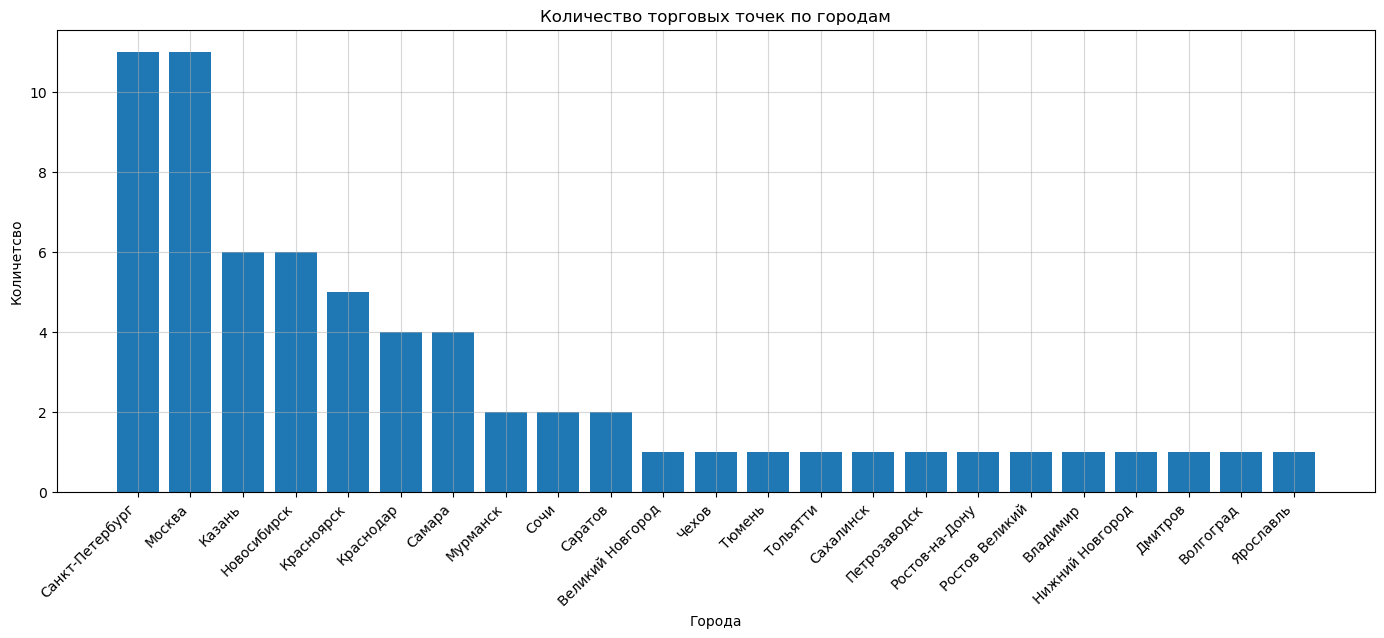

In [18]:
fig, ax = plt.subplots(figsize = (17,6))
ax.bar(cnt_trading_points['city'], cnt_trading_points['cnt_points'])
ax.set_xlabel('Города')
ax.set_ylabel('Количетсво')
ax.set_title('Количество торговых точек по городам')
plt.xticks(rotation = 45, ha='right')
plt.grid(alpha = 0.5)
plt.show()

## 4. Объединение данных

In [19]:
total_spendings = operations\
    .groupby('id_client')\
    .agg(amt_sum = ('amt_payment', 'sum'))\
    .reset_index()
total_spendings

,id_client,amt_sum
0,178561,3052.0
1,178562,2439.0
2,178563,768.0
3,178565,958.0
4,178566,5474.0
...,...,...
28378,209630,6927.0
28379,209631,2090.0
28380,209632,2775.0
28381,209633,1673.0


In [20]:
general_data = clients.merge(total_spendings, on = 'id_client', how = 'left').fillna(0)
general_data

,id_client,dtime_ad,nflag_test,id_trading_point,amt_sum
0,180844,2022-06-08 18:38:41.414,0,212,5349.0
1,226069,2022-07-11 16:28:38.511,1,54,0.0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0
3,322530,2022-07-08 08:56:08.714,0,1015,0.0
4,254313,2022-06-19 22:18:01.770,1,453,0.0
...,...,...,...,...,...
55351,193038,2022-07-09 00:31:25.196,0,1015,5846.0
55352,244069,2022-08-08 00:12:31.319,1,991,0.0
55353,189084,2022-06-29 04:34:42.610,1,439,7146.0
55354,182758,2022-06-13 11:28:37.856,1,573,13720.0


In [21]:
print(f"В general_data отображены все клиенты из клиентской базы: {clients.shape[0] == general_data.shape[0]}")

В general_data отображены все клиенты из клиентской базы: True


In [22]:
general_data = general_data.merge(regions, on = 'id_trading_point')
general_data

,id_client,dtime_ad,nflag_test,id_trading_point,amt_sum,city
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск
1,223863,2022-08-20 21:56:54.325,0,212,0.0,Красноярск
2,201715,2022-07-30 19:07:49.264,1,212,4171.0,Красноярск
3,292010,2022-07-26 20:37:16.885,1,212,0.0,Красноярск
4,190438,2022-07-02 12:53:04.753,1,212,6026.0,Красноярск
...,...,...,...,...,...,...
55351,321313,2022-06-17 15:42:47.009,1,1002,0.0,Москва
55352,200856,2022-07-28 14:51:08.149,1,1002,6696.0,Москва
55353,198305,2022-07-22 06:24:33.232,0,1002,3901.0,Москва
55354,201820,2022-07-31 01:25:03.638,0,1002,0.0,Москва


In [23]:
general_data['is_paid'] = np.where(general_data['amt_sum'] > 0, 1, 0)
general_data

,id_client,dtime_ad,nflag_test,id_trading_point,amt_sum,city,is_paid
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,223863,2022-08-20 21:56:54.325,0,212,0.0,Красноярск,0
2,201715,2022-07-30 19:07:49.264,1,212,4171.0,Красноярск,1
3,292010,2022-07-26 20:37:16.885,1,212,0.0,Красноярск,0
4,190438,2022-07-02 12:53:04.753,1,212,6026.0,Красноярск,1
...,...,...,...,...,...,...,...
55351,321313,2022-06-17 15:42:47.009,1,1002,0.0,Москва,0
55352,200856,2022-07-28 14:51:08.149,1,1002,6696.0,Москва,1
55353,198305,2022-07-22 06:24:33.232,0,1002,3901.0,Москва,1
55354,201820,2022-07-31 01:25:03.638,0,1002,0.0,Москва,0


## 5. Подготовка статистических тестов

In [24]:
def test_calc (r1, r2, alpha = 0.05):
    s, p = ttest_ind(r1, r2)
    if p > alpha:
        print('Статистически значимой разницы между средними нет')
    else:
        print('Между данными есть статистически значимая разница')
        if s >= 0:
            print('Среднее контрольной группы больше, чем у тестовой')
        else:
            print('Среднее тестовой группы больше, чем у контрольной')
    return s, p

In [25]:
def mann_whitney_func (r1, r2, alpha = 0.05):
    w, p = mannwhitneyu(r1, r2)
    if p > alpha:
        print('Статистически значимой разницы между данными нет')
    else:
        print('Между данными есть статистически значимая разница')
    return w, p

## 6. Чистка неверно заполненных точек

In [26]:
# точки, в которых в тестовой или в контрольной группе не было заплачено ни одного рубля ни одним клиентом
zero_payments_points = []

In [27]:
for point in general_data['id_trading_point'].unique():
    point_data = general_data[general_data['id_trading_point'] == point]
    if (point_data[point_data['nflag_test'] == 0]['amt_sum'].sum() == 0) or\
            (point_data[point_data['nflag_test'] == 1]['amt_sum'].sum() == 0):
        zero_payments_points.append(point)
zero_payments_points

[1015, 866, 1099, 739, 46, 228, 26, 603, 810, 800, 7, 23, 4, 1, 13]

In [28]:
# точки, в которых пустует или контрольная, или тестовая группа
empty_groups_points = []

In [29]:
for point in general_data['id_trading_point'].unique():
    point_data = general_data[general_data['id_trading_point'] == point]
    if (len(point_data[point_data['nflag_test'] == 0]) == 0) or (len(point_data[point_data['nflag_test'] == 1]) == 0):
        empty_groups_points.append(point)
empty_groups_points

[1015, 866, 1099, 739, 228, 603, 810, 800]

In [30]:
bad_points = set(zero_payments_points + empty_groups_points)
bad_points

{1, 4, 7, 13, 23, 26, 46, 228, 603, 739, 800, 810, 866, 1015, 1099}

In [31]:
general_data_clean = general_data[~general_data['id_trading_point'].isin(bad_points)]
general_data_clean

,id_client,dtime_ad,nflag_test,id_trading_point,amt_sum,city,is_paid
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,223863,2022-08-20 21:56:54.325,0,212,0.0,Красноярск,0
2,201715,2022-07-30 19:07:49.264,1,212,4171.0,Красноярск,1
3,292010,2022-07-26 20:37:16.885,1,212,0.0,Красноярск,0
4,190438,2022-07-02 12:53:04.753,1,212,6026.0,Красноярск,1
...,...,...,...,...,...,...,...
55351,321313,2022-06-17 15:42:47.009,1,1002,0.0,Москва,0
55352,200856,2022-07-28 14:51:08.149,1,1002,6696.0,Москва,1
55353,198305,2022-07-22 06:24:33.232,0,1002,3901.0,Москва,1
55354,201820,2022-07-31 01:25:03.638,0,1002,0.0,Москва,0


## 7. Расчет общих результатов A/B-теста

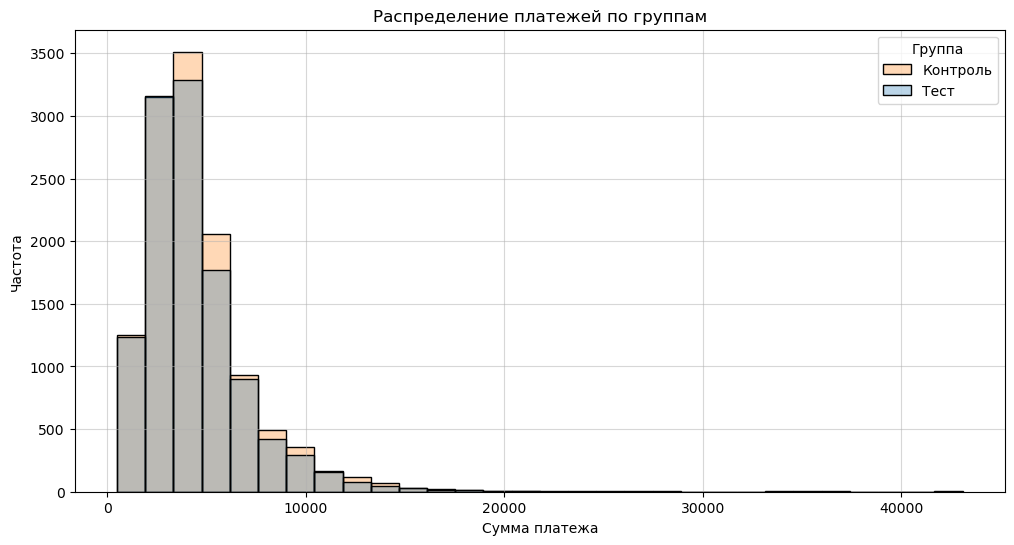

In [32]:
fig, ax = plt.subplots(figsize=(12,6))
# Для построения графиков будем учитывать только случившиеся платежи: amt_sum > 0
sns.histplot(data=general_data_clean[general_data_clean['amt_sum'] > 0], x='amt_sum', hue='nflag_test', bins=30, alpha=0.3)
ax.set_title('Распределение платежей по группам')
ax.set_xlabel('Сумма платежа')
ax.set_ylabel('Частота')
ax.legend(title='Группа', labels=['Контроль', 'Тест'])
plt.grid(alpha = 0.5)
plt.show()

Для сравнения средних используется t-критерий. Это допущение оправдано большим размером выборки, что, согласно ЦПТ, приводит распределение средних к нормальному. 

In [33]:
t_s_amt, t_p_val_amt = ttest_ind(\
                   general_data_clean[general_data_clean['nflag_test'] == 0]['amt_sum'],\
                   general_data_clean[general_data_clean['nflag_test'] == 1]['amt_sum'])

In [34]:
print(f"""
t-критерий: {t_s_amt}, p_value: {t_p_val_amt}
Средний платёж по контрольной выборке: {general_data_clean[general_data_clean['nflag_test'] == 0]['amt_sum'].mean():.2f}
Средний платёж по тестовой выборке: {general_data_clean[general_data_clean['nflag_test'] == 1]['amt_sum'].mean():.2f}
""")


t-критерий: -9.456798235171377, p_value: 3.3214645838934018e-21
Средний платёж по контрольной выборке: 2189.19
Средний платёж по тестовой выборке: 2452.28



Средний платёж по тестовой выборке статистически выше, чем по контрольной.

In [35]:
t_s_conv, t_p_val_conv = ttest_ind(\
                   general_data_clean[general_data_clean['nflag_test'] == 0]['is_paid'],\
                   general_data_clean[general_data_clean['nflag_test'] == 1]['is_paid'])

In [36]:
print(f"""
t-критерий: {t_s_conv}, p_value: {t_p_val_conv}
Конверсия в покупку по контрольной выборке: {general_data_clean[general_data_clean['nflag_test'] == 0]['is_paid'].mean():.3f}
Конверсия в покупку по тестовой выборке: {general_data_clean[general_data_clean['nflag_test'] == 1]['is_paid'].mean():.3f}
""")


t-критерий: -9.282032730948323, p_value: 1.7338073027564523e-20
Конверсия в покупку по контрольной выборке: 0.500
Конверсия в покупку по тестовой выборке: 0.543



Конверсия в покупку по тестовой выборке стаатистически выше конверсии по контрольной выборке.

In [37]:
mw_w, mw_p_val = mannwhitneyu(\
                   general_data_clean[general_data_clean['nflag_test'] == 0]['amt_sum'],\
                   general_data_clean[general_data_clean['nflag_test'] == 1]['amt_sum'])

In [38]:
print(f"Критерий Манна-Уитни: {mw_w}, p_value: {mw_p_val}")

Критерий Манна-Уитни: 243344369.0, p_value: 3.008345273971901e-24


In [39]:
general_data_clean[general_data_clean['nflag_test'] == 0]['amt_sum'].describe()

count    22873.000000
mean      2189.188432
std       2892.151567
min          0.000000
25%          0.000000
50%          0.000000
75%       3774.000000
max      38664.000000
Name: amt_sum, dtype: float64

In [40]:
general_data_clean[general_data_clean['nflag_test'] == 1]['amt_sum'].describe()

count    22445.000000
mean      2452.277345
std       3029.633084
min          0.000000
25%          0.000000
50%       1669.000000
75%       4060.000000
max      43083.000000
Name: amt_sum, dtype: float64

Статистика показывает, что за период акции вплоть до половины клиентов в тестовой группе и больше половины в контрольной так и не совершили ни одной покупки. 

По тем покупкам, что есть, можно сделать вывод: чек в тестовой группе вероятнее окажется выше чека в контрольной группе.

## 8. Сегментация результатов A/B-теста по городам

### 8.1. Подготовка и сбор результатов

In [41]:
def city_analysis(city, df):
    test = df[(df['nflag_test'] == 1) & (df['city'] == city)]
    control = df[(df['nflag_test'] == 0) & (df['city'] == city)]
    
    t_ar, p_ar = ttest_ind(control['amt_sum'], test['amt_sum'])
    
    t_conv, p_conv = ttest_ind(control['is_paid'], test['is_paid'])
    
    mw, p_mw = mannwhitneyu(control['amt_sum'], test['amt_sum'])
    
    return {
        'city': city,
        'T_AR': round(t_ar, 2), 'p_val_AR': p_ar,
        'AR_control': round(control['amt_sum'].mean(), 2),
        'AR_test': round(test['amt_sum'].mean(), 2),
        'T_conv': round(t_conv, 2), 'p_val_conv': p_conv,
        'conv_control': round(control['is_paid'].mean(), 3),
        'conv_test': round(test['is_paid'].mean(), 3),
        'MW': round(mw, 2), 'MW_p_val': p_mw,
        'med_control': round(control['amt_sum'].median(), 2),
        'med_test': round(test['amt_sum'].median(), 2)
    }

In [42]:
city_results = [city_analysis(city, general_data_clean) for city in general_data_clean['city'].unique()]
df_city_results = pd.DataFrame(city_results)
df_city_results.sort_values('city')

,city,T_AR,p_val_AR,AR_control,AR_test,T_conv,p_val_conv,conv_control,conv_test,MW,MW_p_val,med_control,med_test
10,Владимир,-2.58,1.009511e-02,2108.61,2547.22,-1.72,8.481594e-02,0.498,0.550,143847.0,3.166761e-02,0.0,1861.0
8,Волгоград,2.09,3.686900e-02,2601.76,2288.87,1.62,1.049889e-01,0.596,0.553,245743.0,3.323940e-02,2175.0,1576.0
14,Дмитров,-0.33,7.410763e-01,483.45,579.33,-0.33,7.429421e-01,0.099,0.115,2722.0,7.422552e-01,0.0,0.0
2,Казань,-1.07,2.866880e-01,2610.69,2731.91,-0.27,7.848298e-01,0.475,0.479,3178575.0,3.772600e-01,0.0,0.0
12,Краснодар,1.72,8.580011e-02,2912.43,2696.80,1.88,6.038528e-02,0.653,0.614,609837.0,5.938102e-02,2754.0,2448.5
0,Красноярск,-0.12,9.044824e-01,2428.78,2437.50,0.28,7.805337e-01,0.561,0.558,4413418.0,8.770470e-01,1928.5,1899.0
4,Москва,-7.68,1.757549e-14,1986.18,2367.96,-6.19,6.194689e-10,0.488,0.544,17582441.5,7.010591e-16,0.0,1725.5
1,Мурманск,-0.07,9.449762e-01,1857.22,1865.27,-0.85,3.976423e-01,0.419,0.437,554067.5,5.434252e-01,0.0,0.0
11,Самара,-11.54,1.101402e-29,1718.42,3262.79,-11.85,3.981450e-31,0.440,0.717,233516.5,4.325202e-30,0.0,3022.0
3,Санкт-Петербург,-8.76,2.319809e-18,1913.56,2427.46,-9.35,1.065826e-20,0.448,0.547,8809444.5,2.039218e-20,0.0,1702.0


Талица с результатами статистических тестов по всем городам.

In [43]:
def res_iterpretation(p_val, stat, is_mann=False, med1=None, med2=None):
    if p_val >= 0.05:
        return 0
    if is_mann:
        return 1 if med1 < med2 else -1
    return 1 if stat <= 0 else -1

In [44]:
df_city_results['AR_is_more'] =\
    df_city_results.apply(lambda row: res_iterpretation(row['p_val_AR'], row['T_AR']), axis=1)

In [45]:
df_city_results['conversion_is_more'] =\
    df_city_results.apply(lambda row: res_iterpretation(row['p_val_conv'], row['T_conv']), axis=1)

In [46]:
df_city_results['shift'] =\
    df_city_results.apply(lambda row: res_iterpretation(row['MW_p_val'], None, True, row['med_control'], row['med_test']), axis=1)

### 8.2. Интерпретация результатов.

In [47]:
df_city_interpretation = df_city_results[['city', 'AR_is_more', 'conversion_is_more', 'shift']]
df_city_interpretation.sort_values('city')

,city,AR_is_more,conversion_is_more,shift
10,Владимир,1,0,1
8,Волгоград,-1,0,-1
14,Дмитров,0,0,0
2,Казань,0,0,0
12,Краснодар,0,0,0
0,Красноярск,0,0,0
4,Москва,1,1,1
1,Мурманск,0,0,0
11,Самара,1,1,1
3,Санкт-Петербург,1,1,1


Результаты исследования.

Средний чек стал статистически выше в 4 городах из 15: Москва, Санкт-Петербург, Самара, Владимир. В Волгограде средний чек статистически стал меньше.

Конверсия в покупку увеличилась тоже в 4 городах из 15: Москва, Санкт-Петербург, Самара, Тюмень. В Сочи конверсия в покупку уменьшилась.

Если рассматривать выборки в целом: где значения выше, а где ниже, то в 5 городах из 15 (Москва, Санкт-Петербург, Самара, Владимир, Тюмень) клиенты тестовой группы покупаеют на большие суммы, чем клиенты из контрольной группы. В Волгограде, наоборот, клиенты тратят статичстически меньшие суммы на покупки.

В остальном изменений не обнаружено.

Вывод: изменение, связанное с рассылкой уведомлений, по большей части имело успех в столичных городах и не оказало статистически значимого влияния на потребительское поведение в регионах.


Город: Красноярск


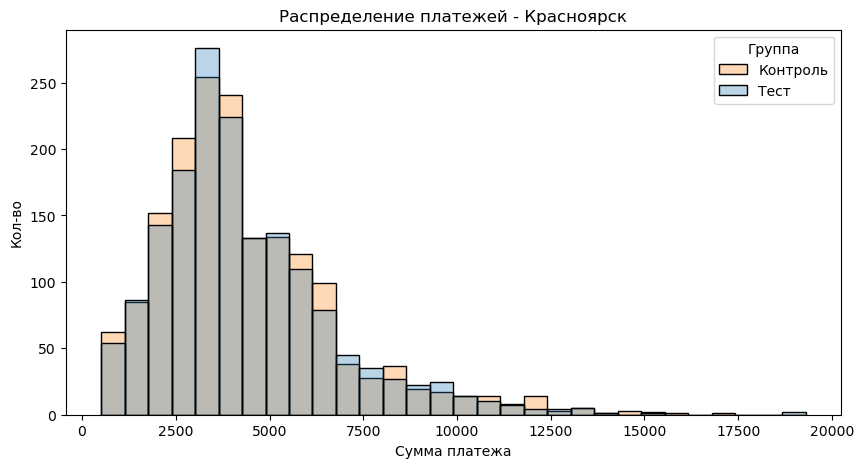


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Мурманск


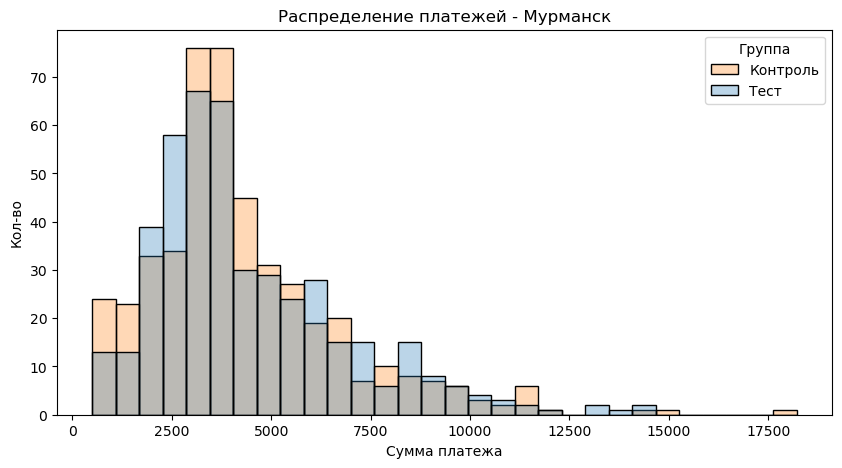


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Казань


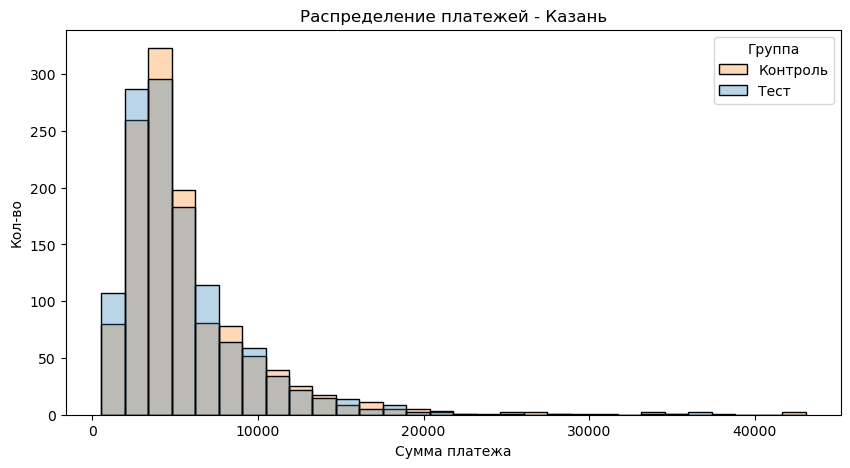


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Санкт-Петербург


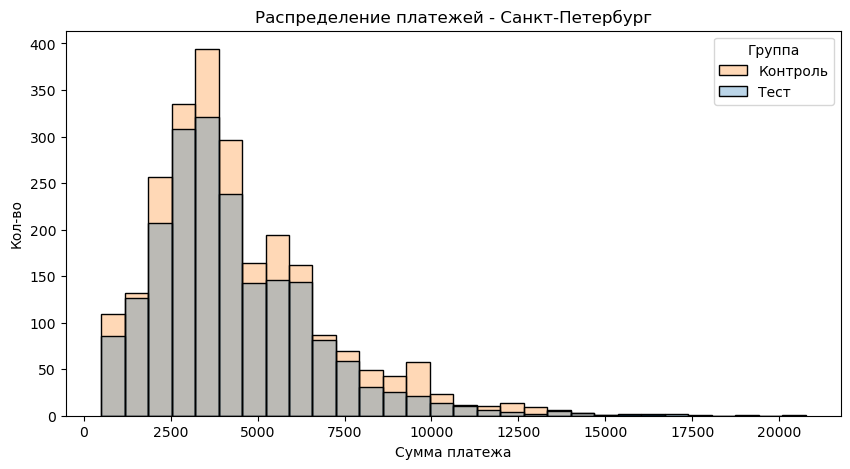


--- Сравнение среднего чека (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестовой группы больше, чем у контрольной

--- Сравнение распределений (Манна-Уитни) ---
Между данными есть статистически значимая разница

--- Сравнение конверсии (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестовой группы больше, чем у контрольной

Город: Москва


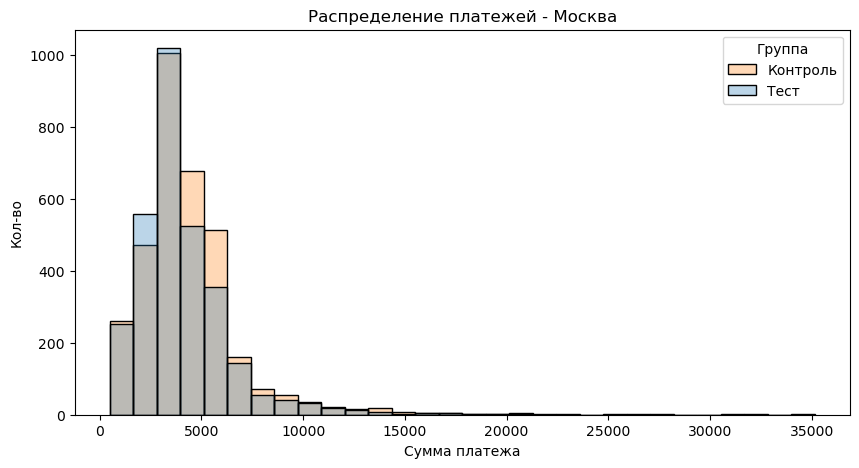


--- Сравнение среднего чека (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестовой группы больше, чем у контрольной

--- Сравнение распределений (Манна-Уитни) ---
Между данными есть статистически значимая разница

--- Сравнение конверсии (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестовой группы больше, чем у контрольной

Город: Саратов


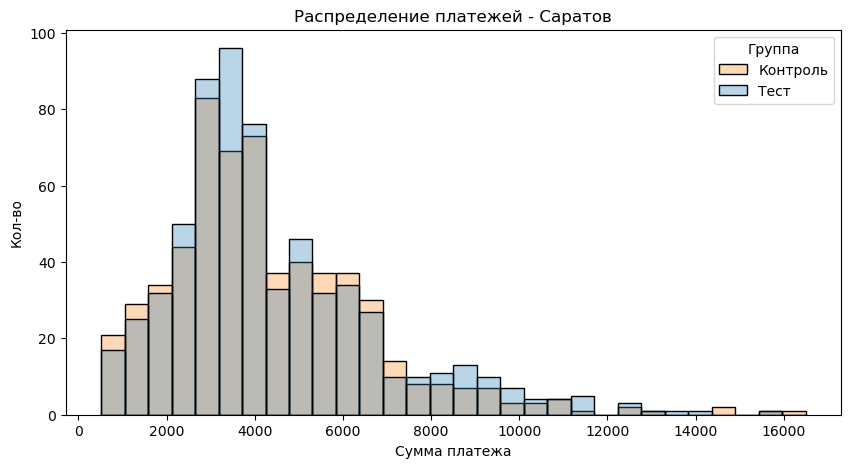


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Тольятти


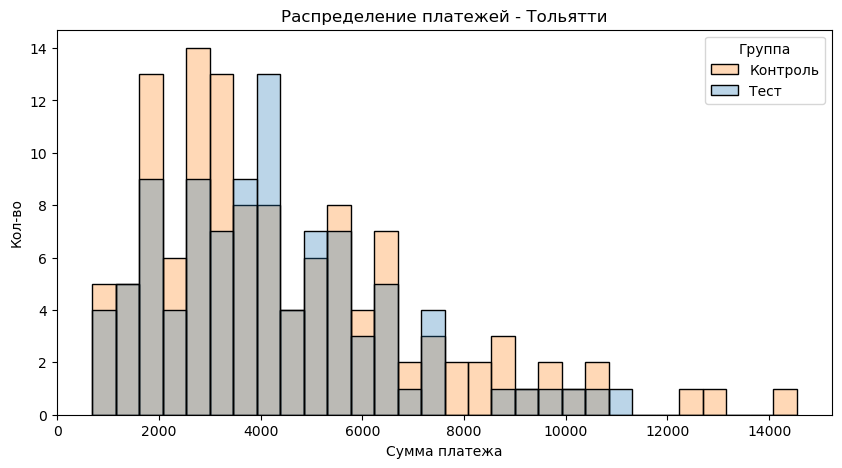


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Тюмень


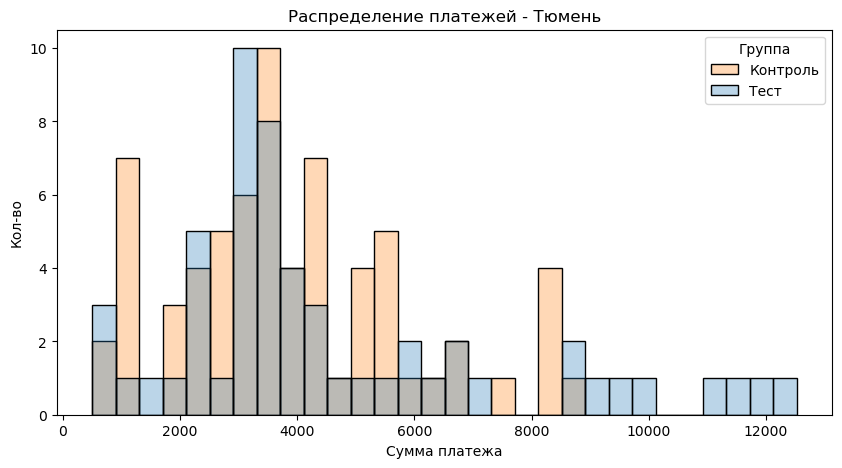


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Между данными есть статистически значимая разница

--- Сравнение конверсии (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестовой группы больше, чем у контрольной

Город: Волгоград


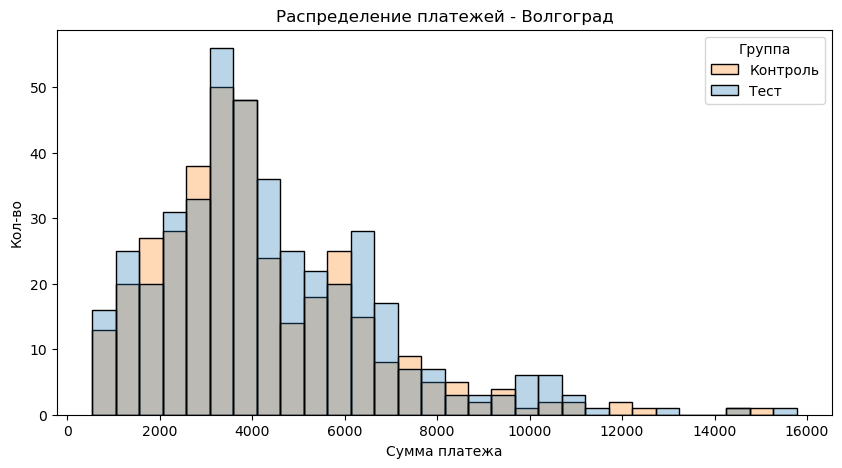


--- Сравнение среднего чека (t-тест) ---
Между данными есть статистически значимая разница
Среднее контрольной группы больше, чем у тестовой

--- Сравнение распределений (Манна-Уитни) ---
Между данными есть статистически значимая разница

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Сочи


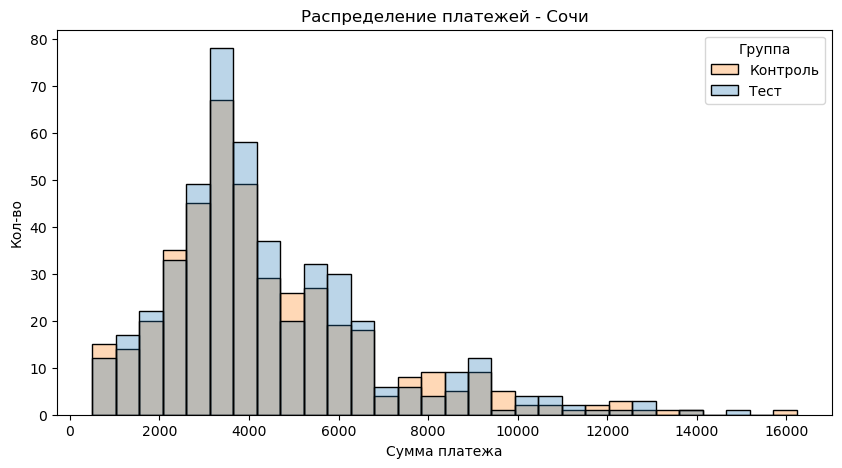


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Между данными есть статистически значимая разница
Среднее контрольной группы больше, чем у тестовой

Город: Владимир


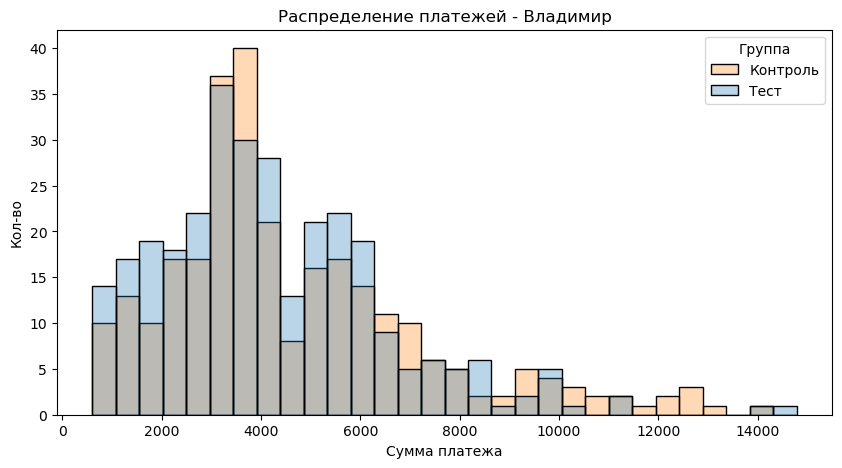


--- Сравнение среднего чека (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестовой группы больше, чем у контрольной

--- Сравнение распределений (Манна-Уитни) ---
Между данными есть статистически значимая разница

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Самара


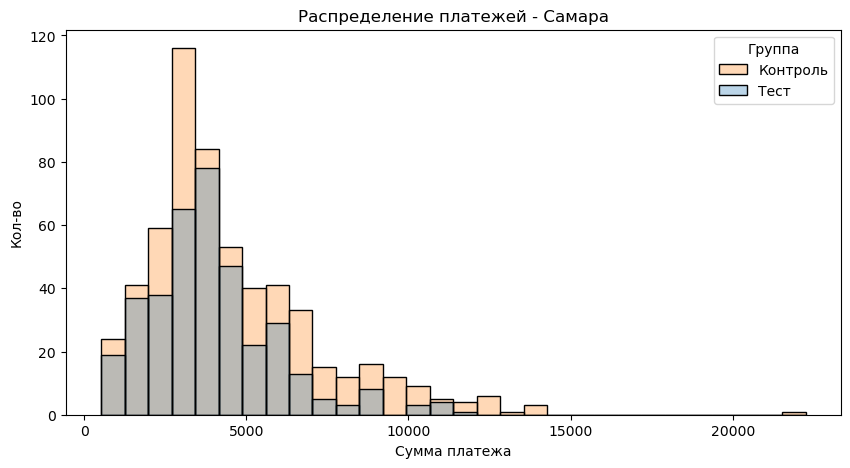


--- Сравнение среднего чека (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестовой группы больше, чем у контрольной

--- Сравнение распределений (Манна-Уитни) ---
Между данными есть статистически значимая разница

--- Сравнение конверсии (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестовой группы больше, чем у контрольной

Город: Краснодар


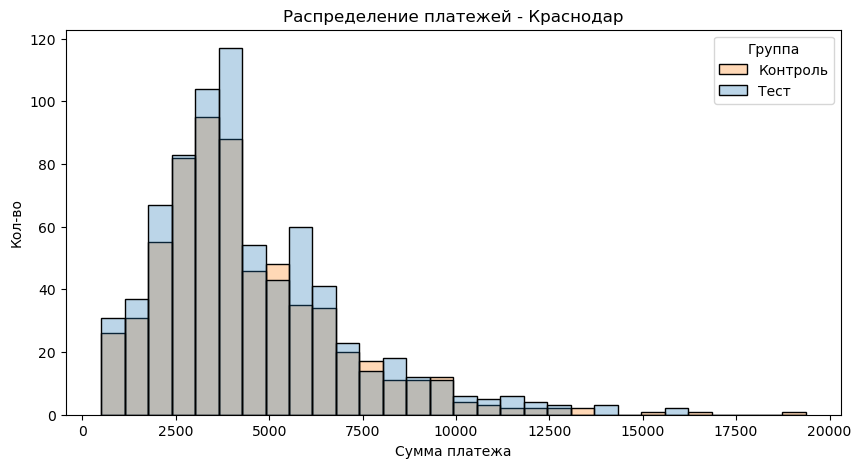


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Сахалинск


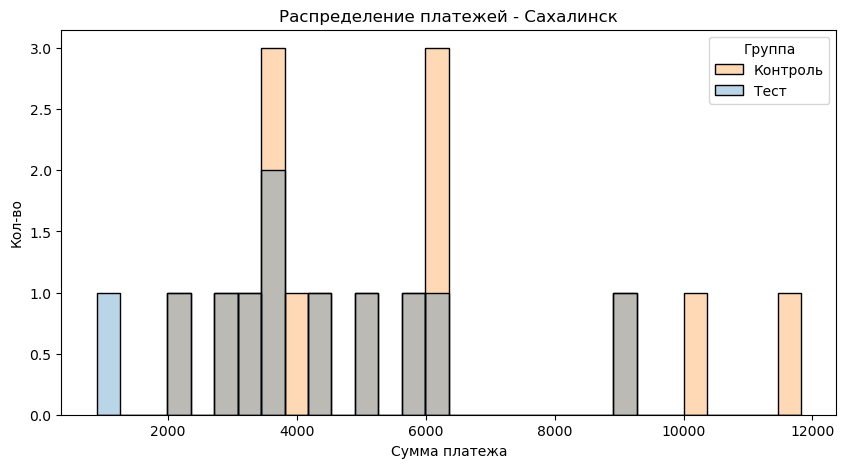


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Дмитров


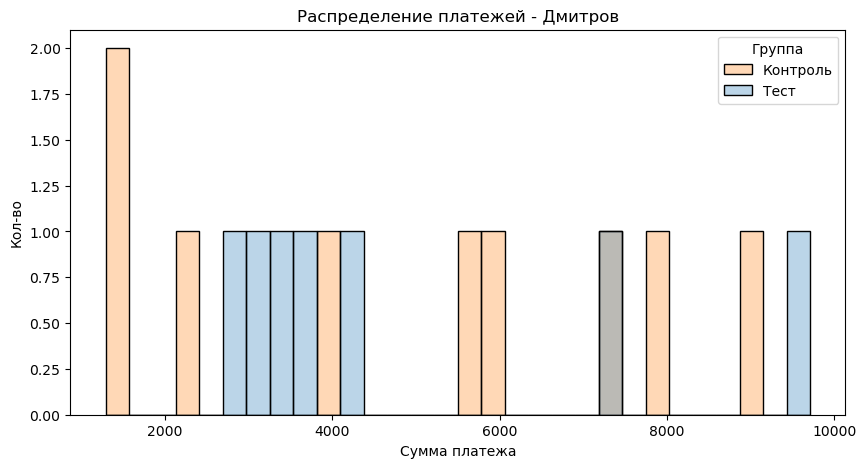


--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет

--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет

--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет


In [48]:
# Графики и тесты по городам:
for city in general_data_clean['city'].unique():
    print(f"\n{'='*50}")
    print(f"Город: {city}")
    print('='*50)
    
    city_data = general_data_clean[general_data_clean['city'] == city]
    
    plt.figure(figsize=(10,5))
    # Для графика оставим только ту часть, где amt_sum > 0
    sns.histplot(data=city_data[city_data['amt_sum'] > 0], x='amt_sum', hue='nflag_test',bins=30, alpha=0.3)
    plt.title(f'Распределение платежей - {city}')
    plt.xlabel('Сумма платежа')
    plt.ylabel('Кол-во')
    plt.legend(title='Группа', labels=['Контроль', 'Тест'])
    plt.show()
    
    print("\n--- Сравнение среднего чека (t-тест) ---")
    test_calc(city_data[city_data['nflag_test']==0]['amt_sum'], 
              city_data[city_data['nflag_test']==1]['amt_sum'])
    
    print("\n--- Сравнение распределений (Манна-Уитни) ---")
    mann_whitney_func(city_data[city_data['nflag_test']==0]['amt_sum'], 
                      city_data[city_data['nflag_test']==1]['amt_sum'])
    
    print("\n--- Сравнение конверсии (t-тест) ---")
    test_calc(city_data[city_data['nflag_test']==0]['is_paid'], 
              city_data[city_data['nflag_test']==1]['is_paid'])

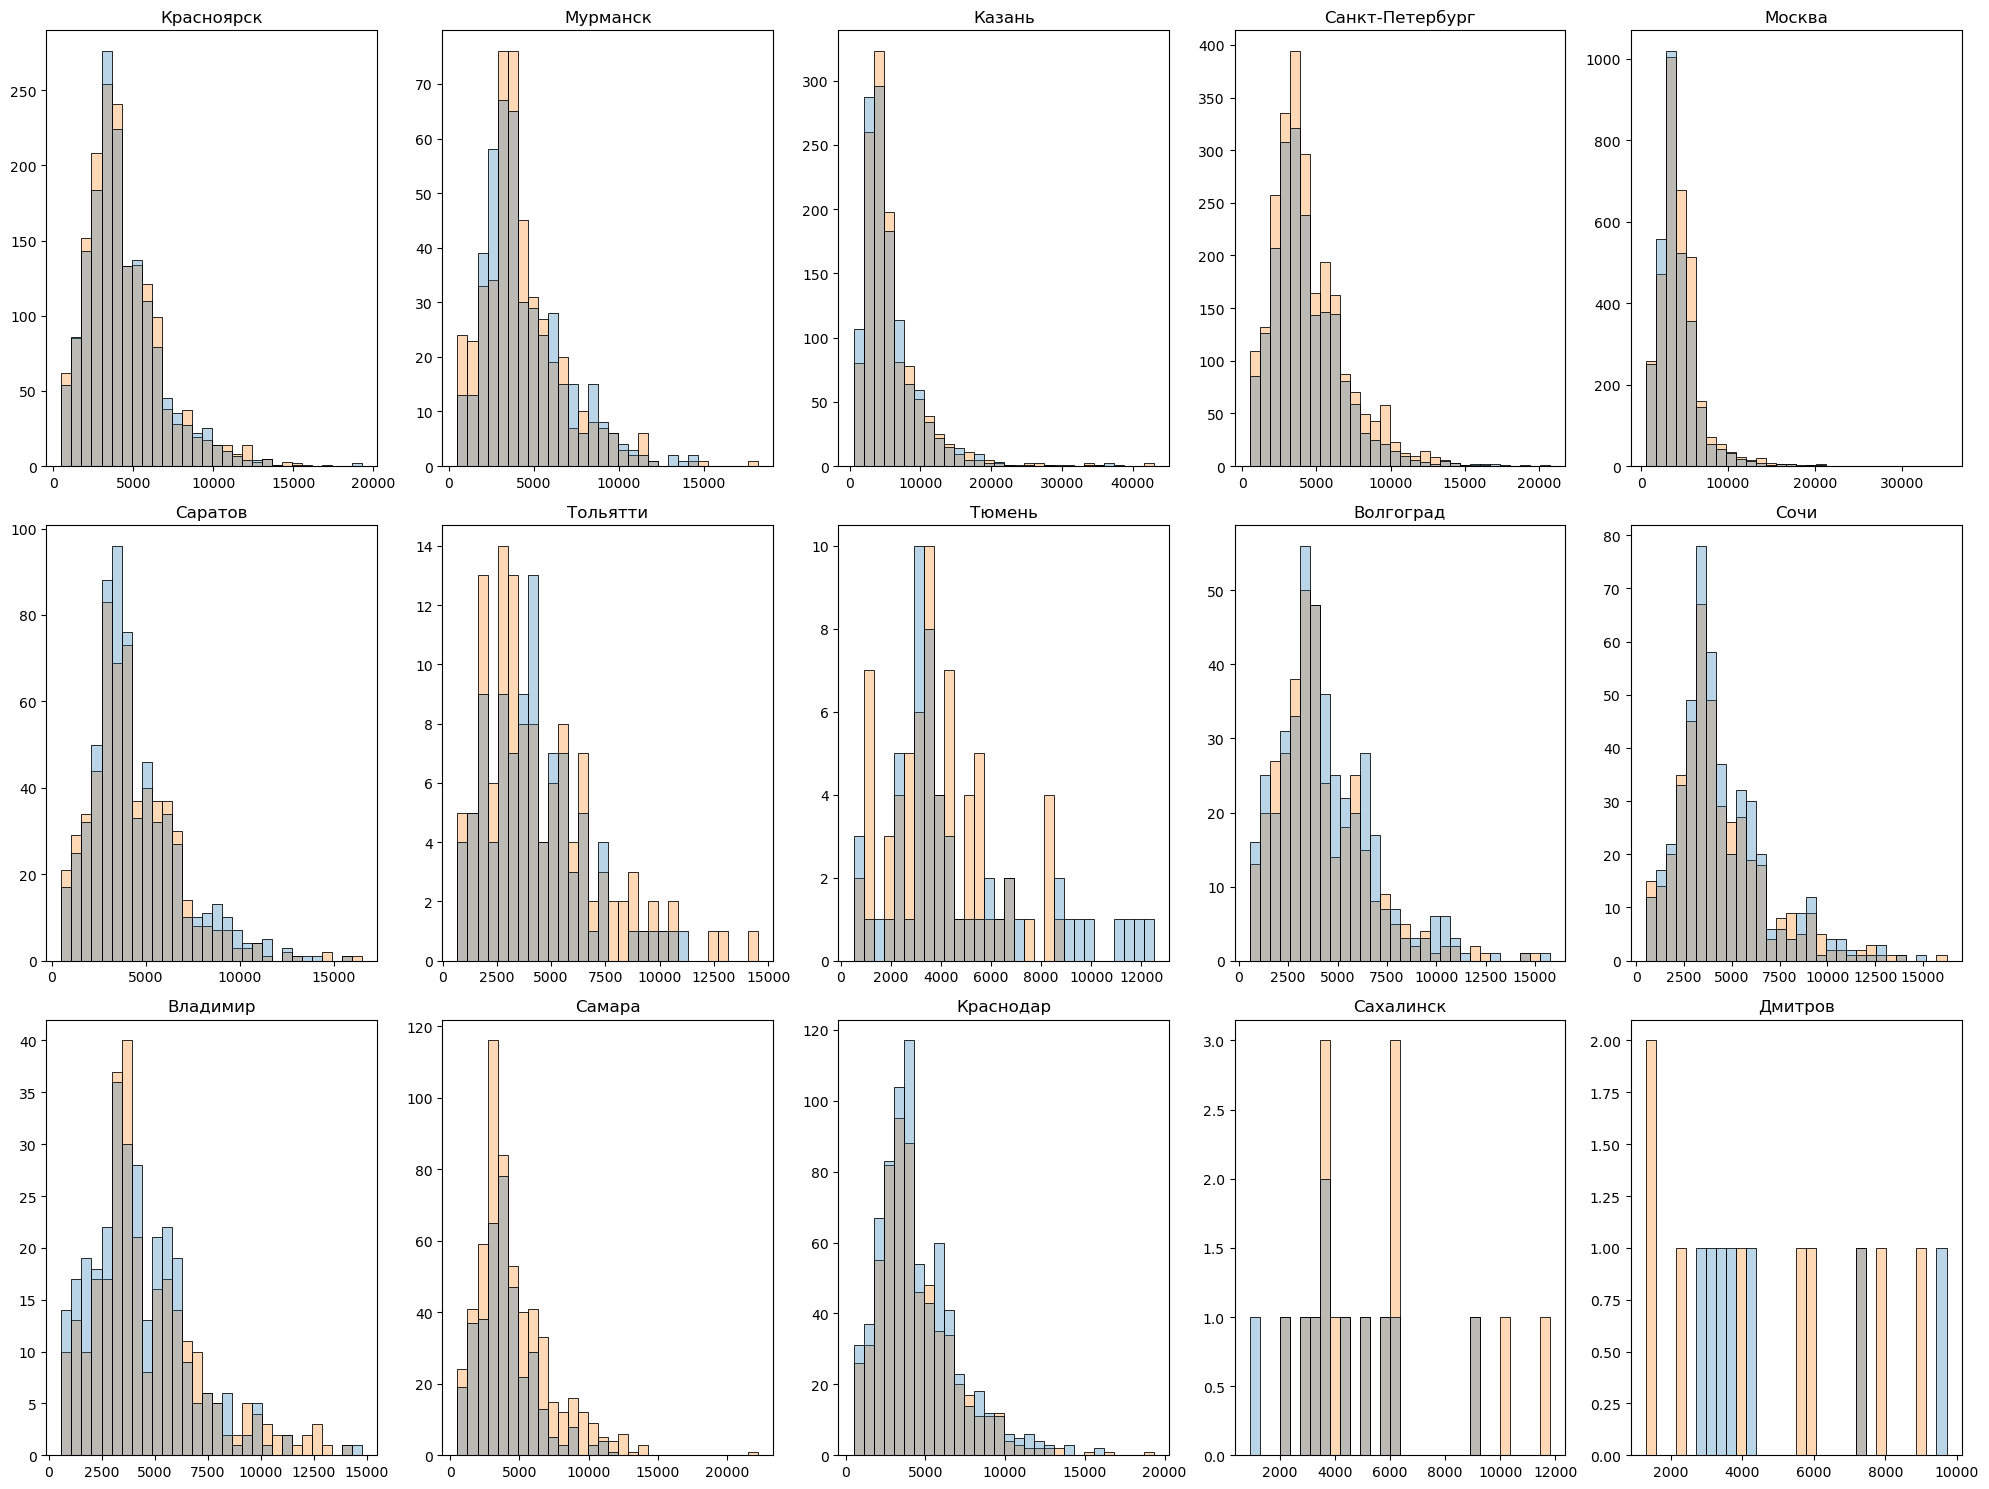


Город: Красноярск
--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет
--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет
--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Мурманск
--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет
--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет
--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Казань
--- Сравнение среднего чека (t-тест) ---
Статистически значимой разницы между средними нет
--- Сравнение распределений (Манна-Уитни) ---
Статистически значимой разницы между данными нет
--- Сравнение конверсии (t-тест) ---
Статистически значимой разницы между средними нет

Город: Санкт-Петербург
--- Сравнение среднего чека (t-тест) ---
Между данными есть статистически значимая разница
Среднее тестово

In [49]:
# Компактнее:

cities = general_data_clean['city'].unique()
n_cities = len(cities)
rows = (n_cities + 3) // 5  # 5 графиков в строку
cols = min(5, n_cities)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows*5))
axes = axes.flatten() if rows > 1 else [axes] if n_cities > 1 else [axes]

for i, city in enumerate(cities):
    city_data = general_data_clean[general_data_clean['city'] == city]
    city_data_positive = city_data[city_data['amt_sum'] > 0]
    
    sns.histplot(data=city_data_positive, x='amt_sum', hue='nflag_test', 
                 bins=30, alpha=0.3, ax=axes[i], legend=False)
    axes[i].set_title(city)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

for city in cities:
    print(f"\n{'='*50}")
    print(f"Город: {city}")
    print('='*50)
    city_data = general_data_clean[general_data_clean['city'] == city]
    
    print("--- Сравнение среднего чека (t-тест) ---")
    test_calc(city_data[city_data['nflag_test']==0]['amt_sum'], 
              city_data[city_data['nflag_test']==1]['amt_sum'])
    
    print("--- Сравнение распределений (Манна-Уитни) ---")
    mann_whitney_func(city_data[city_data['nflag_test']==0]['amt_sum'], 
                      city_data[city_data['nflag_test']==1]['amt_sum'])
    
    print("--- Сравнение конверсии (t-тест) ---")
    test_calc(city_data[city_data['nflag_test']==0]['is_paid'], 
              city_data[city_data['nflag_test']==1]['is_paid'])

## 9. Сегментация по торговым точкам и итоговый отчёт.

### 9.1. Подготовка и сбор результатов

In [50]:
def point_analysis(point):
    
    data = general_data_clean[general_data_clean['id_trading_point'] == point]
    
    city = data['city'].iloc[0]
    
    test = data[data['nflag_test'] == 1]
    control = data[data['nflag_test'] == 0]
    
    count_test = len(test)
    count_control = len(control)
    count_all = count_test + count_control
    percent_count = count_all / len(general_data_clean)
    
    avg_payment_test = test['amt_sum'].mean()
    avg_payment_control = control['amt_sum'].mean()
    diff = avg_payment_test - avg_payment_control
    
    sigma_test = test['amt_sum'].std()
    sigma_control = control['amt_sum'].std()
    
    t_stat, p_val = ttest_ind(test['amt_sum'], control['amt_sum'])
    
    if p_val < 0.05:
        if diff > 0:
            label = 'positive'
        else:
            label = 'negative'
    else:
        label = 'neutral'
    
    return [city, point, count_test, count_control, count_all, percent_count,
            avg_payment_test, avg_payment_control, diff, sigma_test, sigma_control,
            t_stat, p_val, label]

In [51]:
columns = ['city', 'id_trading_point', 'count_test', 'count_control', 'count_all',
           'percent_count', 'avg_payment_test', 'avg_payment_control', 'diff',
           'sigma_test', 'sigma_control', 'ttest', 'pvalue_ttest', 'label']

results = []

for point in general_data_clean['id_trading_point'].unique():
    results.append(point_analysis(point))

df_final = pd.DataFrame(results, columns=columns)
df_final

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,label
0,Красноярск,212,593,575,1168,0.025773,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,-0.483585,6.287709e-01,neutral
1,Мурманск,54,633,640,1273,0.028090,1702.714060,1688.512500,14.201560,2565.132440,2628.012490,0.097556,9.223005e-01,neutral
2,Казань,991,270,294,564,0.012445,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,2.255258,2.450100e-02,positive
3,Санкт-Петербург,453,1066,1049,2115,0.046670,2501.966229,1889.923737,612.042492,2993.442540,2648.659303,4.976910,6.983207e-07,positive
4,Москва,2652,2273,2370,4643,0.102454,2506.616806,1972.847679,533.769127,2842.182948,2565.878242,6.722230,2.005922e-11,positive
5,Красноярск,278,535,489,1024,0.022596,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,1.820268,6.901056e-02,neutral
6,Москва,6543,662,689,1351,0.029812,1702.439577,1528.325109,174.114468,2453.901717,2338.522063,1.335377,1.819782e-01,neutral
7,Казань,699,482,494,976,0.021537,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,-0.594254,5.524804e-01,neutral
8,Казань,477,382,386,768,0.016947,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,-0.891593,3.728909e-01,neutral
9,Казань,544,377,416,793,0.017499,2621.427056,2635.548077,-14.121021,3714.894751,4639.820746,-0.046997,9.625274e-01,neutral


### 9.2. Экспорт итогов.

In [52]:
with pd.ExcelWriter('../results/ab_test_results.xlsx', engine='xlsxwriter') as writer:
    for label in ['positive', 'negative', 'neutral']:
        df_final[df_final['label'] == label].to_excel(writer, sheet_name=label, index=False)